In [ ]:
# ── Path bootstrap (added during folder-structure refactor) ─────────
# Ensures `bb84` / `prep` packages are importable when this notebook
# is launched from the experiments/ folder.
import sys
from pathlib import Path
_PROJ_ROOT = Path.cwd().parent if Path.cwd().name == 'experiments' else Path.cwd()
if str(_PROJ_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJ_ROOT))


# BB84 QKD Simulator — Phase 3: Noisy Quantum Systems
**University of Ruhuna  ·  Dept. of Computer Engineering**

---

## Objectives (this notebook)
1. **Understand** how real physical noise mechanisms affect BB84 security
2. **Visualise** QBER changes under different noise conditions
3. **Compare** depolarizing, amplitude damping, phase damping, and fibre loss
4. **Analyse** the Lindblad master equation connection to each noise model

---

## The Lindblad Master Equation

Real qubits are **open quantum systems** — they interact with the environment. Instead of unitary evolution, the qubit density matrix ρ evolves as:

$$\frac{d\rho}{dt} = -\frac{i}{\hbar}[H, \rho] \;+\; \sum_k \gamma_k \left( L_k \rho L_k^\dagger - \frac{1}{2}\{L_k^\dagger L_k,\, \rho\} \right)$$

Each noise channel corresponds to a specific **jump operator** $L_k$:

| Noise model | Jump operator $L_k$ | Parameter | Physical meaning |
|---|---|---|---|
| Depolarizing | $X, Y, Z$ (equal) | $p$ per gate | Random Pauli errors |
| Amplitude damping | $\sqrt{\gamma}\,|0\rangle\langle 1|$ | $\gamma = 1 - e^{-t/T_1}$ | Energy relaxation (excited state decays) |
| Phase damping | $\sqrt{\lambda}\,|1\rangle\langle 1|$ | $\lambda = 1 - e^{-t/T_2}$ | Dephasing (phase coherence lost) |
| Combined | Both above | $T_1, T_2$ | Realistic qubit decoherence |

**Key insight:** Phase damping does NOT flip bits — it only destroys superposition. Amplitude damping does flip bits (|1⟩ → |0⟩). This means they affect BB84 differently depending on which basis is used.

---

## Files required
```
bb84_config.py          ← unchanged from Phase 1
bb84_core.py            ← unchanged from Phase 1  
bb84_noise.py           ← NEW in Phase 3
bb84_runner.py          ← updated in Phase 3
bb84_phase3_plots.py    ← NEW in Phase 3
```

---
## Cell 1 — Imports

In [1]:
from bb84.config import SimulationConfig
from bb84.noise  import QuantumChannel, NoiseModelType
from bb84.runner import run_simulation, run_comparison, PRESET_SCENARIOS, PHASE3_SCENARIOS
from bb84.phase3_plots import (
    plot_noise_model_comparison,
    plot_qber_vs_depolar_prob,
    plot_qber_vs_t1,
    plot_qber_vs_t2,
    plot_fiber_loss_analysis,
)

---
## Cell 2 — Inspect channel descriptions (no simulation needed)

Before running any simulations, see how each noise model is parameterised.

In [ ]:
import math

# Parameters we will use throughout this notebook
T1_NS      = 10_000    # 10 µs  — T1 relaxation time
T2_NS      =  8_000    #  8 µs  — T2 dephasing time   (must be ≤ 2*T1)
GATE_NS    =     50    # 50 ns  — single-qubit gate time
DEPOLAR_P  =   0.05    # 5 %    — depolarizing error probability
FIBER_KM   =     50    # 50 km  — fibre channel length

# Compute and print Lindblad parameters
gamma = 1 - math.exp(-GATE_NS / T1_NS)
lam   = 1 - math.exp(-GATE_NS / T2_NS)

print("Lindblad parameters for our hardware settings")
print("──────────────────────────────────────────────")
print(f"  T1        = {T1_NS/1000:.0f} µs    T2 = {T2_NS/1000:.0f} µs    gate = {GATE_NS} ns")
print(f"  γ (amp.damp) = 1 − exp(−{GATE_NS}/{T1_NS}) = {gamma:.6f}")
print(f"  λ (phase.damp)= 1 − exp(−{GATE_NS}/{T2_NS}) = {lam:.6f}")
print(f"  depolarizing p = {DEPOLAR_P}")
print(f"  fibre: P_survive = 10^(-0.2×{FIBER_KM}/10) = {10**(-0.2*FIBER_KM/10):.4f}")

print("\nChannel descriptions")
print("──────────────────────────────────────────────")
channels = [
    QuantumChannel(noise_enabled=False),
    QuantumChannel(noise_enabled=True, noise_model=NoiseModelType.DEPOLARIZING,
                   depolar_prob=DEPOLAR_P),
    QuantumChannel(noise_enabled=True, noise_model=NoiseModelType.AMPLITUDE_DAMP,
                   t1_ns=T1_NS, gate_time_ns=GATE_NS),
    QuantumChannel(noise_enabled=True, noise_model=NoiseModelType.PHASE_DAMP,
                   t2_ns=T2_NS, gate_time_ns=GATE_NS),
    QuantumChannel(noise_enabled=True, noise_model=NoiseModelType.COMBINED,
                   t1_ns=T1_NS, t2_ns=T2_NS, gate_time_ns=GATE_NS),
    QuantumChannel(noise_enabled=True, noise_model=NoiseModelType.FIBER_LOSS,
                   channel_length_km=FIBER_KM),
]
for ch in channels:
    print(f"  {ch.description}")

Lindblad parameters for our hardware settings
──────────────────────────────────────────────
  T1        = 10 µs    T2 = 8 µs    gate = 50 ns
  γ (amp.damp) = 1 − exp(−50/10000) = 0.004988
  λ (phase.damp)= 1 − exp(−50/8000) = 0.006231
  depolarizing p = 0.05
  fibre: P_survive = 10^(−0.2×50/10) = 0.1000

Channel descriptions
──────────────────────────────────────────────
  [Channel] Depolarizing  p = 0.05
  [Channel] Amplitude damping  T1 = 10 µs  γ = 0.0050
  [Channel] Phase damping  T2 = 8 µs  λ = 0.0062
  [Channel] Combined T1/T2  T1 = 10 µs  T2 = 8 µs
  Ideal channel (no noise)
  Depolarizing  p = 0.05
  Amplitude damping  T1 = 10 µs  γ = 0.0050
  Phase damping  T2 = 8 µs  λ = 0.0062
  Combined T1/T2  T1 = 10 µs  T2 = 8 µs
  Fiber loss  L = 50 km  P_survive = 0.100


---
## Cell 3 — Single runs: compare noise models side-by-side

In [3]:
N = 500   # qubits per run

configs = {
    "Ideal": SimulationConfig(n_qubits=N, label="Ideal"),

    "Depolarizing (p=0.05)": SimulationConfig(
        n_qubits=N, noise_enabled=True,
        noise_model=NoiseModelType.DEPOLARIZING, depolar_prob=0.05,
        label="Depolarizing"),

    "Amplitude Damping (T1=10µs)": SimulationConfig(
        n_qubits=N, noise_enabled=True,
        noise_model=NoiseModelType.AMPLITUDE_DAMP,
        t1_ns=10_000, gate_time_ns=50, label="Amp.Damp"),

    "Phase Damping (T2=8µs)": SimulationConfig(
        n_qubits=N, noise_enabled=True,
        noise_model=NoiseModelType.PHASE_DAMP,
        t2_ns=8_000, gate_time_ns=50, label="Phase.Damp"),

    "Combined T1+T2": SimulationConfig(
        n_qubits=N, noise_enabled=True,
        noise_model=NoiseModelType.COMBINED,
        t1_ns=10_000, t2_ns=8_000, gate_time_ns=50, label="Combined"),

    "Fiber Loss (50 km)": SimulationConfig(
        n_qubits=N+200, noise_enabled=True,
        noise_model=NoiseModelType.FIBER_LOSS,
        channel_length_km=50, label="Fiber 50km"),
}

results = {}
print(f"{'Scenario':<30} {'QBER':>6}  {'Key':>5}  {'Agree':>6}  Status")
print("─" * 65)
for name, cfg in configs.items():
    r = run_simulation(cfg, verbose=False)
    results[name] = r
    print(f"{name:<30} {r.qber_result.qber*100:>5.1f}%  "
          f"{r.key_length:>5}b  {r.key_agreement_rate*100:>5.1f}%  "
          f"{r.qber_result.security_status}")

Scenario                         QBER    Key   Agree  Status
─────────────────────────────────────────────────────────────────
Ideal                            0.0%    224b  100.0%  SECURE ok
  [Channel] Depolarizing  p = 0.05
Depolarizing (p=0.05)            4.2%    224b   98.7%  SECURE ok
  [Channel] Amplitude damping  T1 = 10 µs  γ = 0.0050
Amplitude Damping (T1=10µs)      0.0%    224b  100.0%  SECURE ok
  [Channel] Phase damping  T2 = 8 µs  λ = 0.0062
Phase Damping (T2=8µs)           0.0%    224b  100.0%  SECURE ok
  [Channel] Combined T1/T2  T1 = 10 µs  T2 = 8 µs
Combined T1+T2                   0.0%    224b  100.0%  SECURE ok
Fiber Loss (50 km)               0.0%     30b  100.0%  SECURE ok


---
## Cell 4 — Comparison chart across all noise models

In [4]:
fig = plot_noise_model_comparison(
    n_qubits   = 600,
    t1_ns      = 10_000,
    t2_ns      =  8_000,
    gate_ns    =     50,
    depolar_p  =   0.05,
    fiber_km   =     50,
    save_path  = "phase3_noise_comparison.png",
)

  Running noise model comparison...
    Ideal         QBER=0.0%  Key=269b  SECURE ok


KeyboardInterrupt: 

---
## Cell 5 — QBER vs Depolarizing Probability

**Research question:** At what noise level does the channel become insecure?

The 5% threshold (WARNING) is crossed at approximately p ≈ 0.075 for depolarizing noise.

  Sweeping depolarizing probability...
    p=0.000  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.012499999999999999
    p=0.012  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.024999999999999998
    p=0.025  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.0375
    p=0.037  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.049999999999999996
    p=0.050  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.06249999999999999
    p=0.062  →  QBER=10.0%
  [Channel] Depolarizing  p = 0.075
    p=0.075  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.0875
    p=0.087  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.09999999999999999
    p=0.100  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.11249999999999999
    p=0.112  →  QBER=5.0%
  [Channel] Depolarizing  p = 0.12499999999999999
    p=0.125  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.13749999999999998
    p=0.137  →  QBER=10.0%
  [Channel] Depolarizing  p = 0.15
    p=0.150  →  QBER=0.0%
  [✓] Saved → phase3_qber_vs_depolar.png


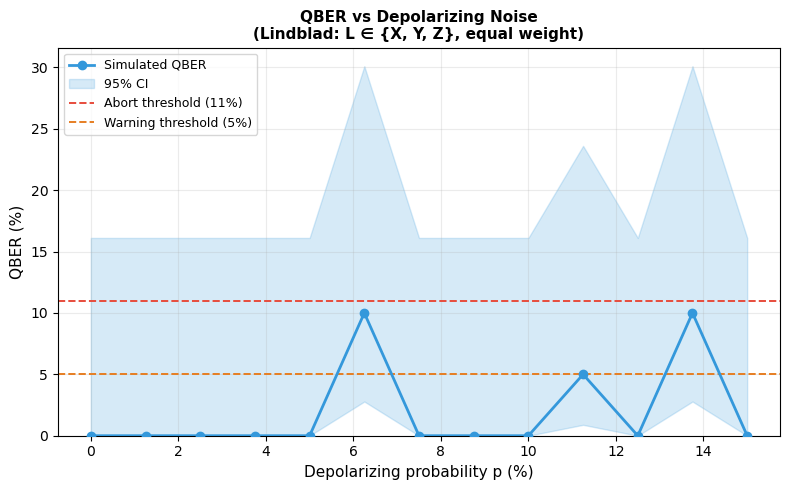

In [5]:
fig = plot_qber_vs_depolar_prob(
    n_qubits  = 400,
    steps     = 12,
    p_max     = 0.15,
    save_path = "phase3_qber_vs_depolar.png",
)

  Sweeping depolarizing probability...
    p=0.000  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.0075
    p=0.007  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.015
    p=0.015  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.0225
    p=0.022  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.03
    p=0.030  →  QBER=0.0%
  [Channel] Depolarizing  p = 0.0375
    p=0.037  →  QBER=1.0%
  [Channel] Depolarizing  p = 0.045
    p=0.045  →  QBER=2.1%
  [Channel] Depolarizing  p = 0.0525
    p=0.052  →  QBER=1.0%
  [Channel] Depolarizing  p = 0.06
    p=0.060  →  QBER=3.1%
  [Channel] Depolarizing  p = 0.0675
    p=0.068  →  QBER=1.0%
  [Channel] Depolarizing  p = 0.075
    p=0.075  →  QBER=2.1%
  [Channel] Depolarizing  p = 0.08249999999999999
    p=0.082  →  QBER=6.2%
  [Channel] Depolarizing  p = 0.09
    p=0.090  →  QBER=1.0%
  [Channel] Depolarizing  p = 0.0975
    p=0.098  →  QBER=1.0%
  [Channel] Depolarizing  p = 0.105
    p=0.105  →  QBER=5.2%
  [Channel] Depolarizing  p = 0.11249999999999999


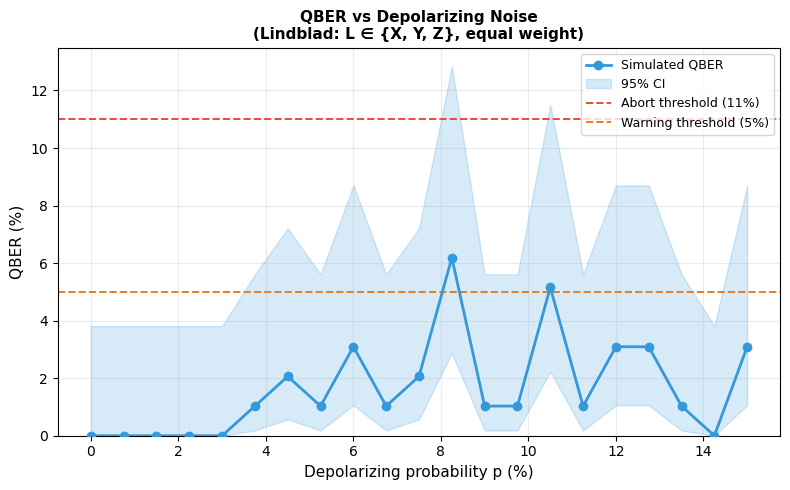

In [13]:
fig = plot_qber_vs_depolar_prob(
    n_qubits  = 2000,    # was 400
    steps     = 20,      # was 12
    p_max     = 0.15,
)

---
## Cell 6 — QBER vs T1 (Amplitude Damping)

**Physical meaning:** How long can the qubit hold its excited state?

- Short T1 → large γ → qubit decays from |1⟩ to |0⟩ mid-flight → high QBER
- Long T1 → small γ → qubit is stable → low QBER  
- Note how the x-axis is **inverted** — left = most noise

  Sweeping T1 (amplitude damping)...
  [Channel] Amplitude damping  T1 = 1 µs  γ = 0.0488
    T1=1µs  γ=0.04877  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 18 µs  γ = 0.0028
    T1=18µs  γ=0.00284  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 34 µs  γ = 0.0015
    T1=34µs  γ=0.00146  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 51 µs  γ = 0.0010
    T1=51µs  γ=0.00098  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 67 µs  γ = 0.0007
    T1=67µs  γ=0.00074  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 84 µs  γ = 0.0006
    T1=84µs  γ=0.00060  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 100 µs  γ = 0.0005
    T1=100µs  γ=0.00050  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 117 µs  γ = 0.0004
    T1=117µs  γ=0.00043  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 134 µs  γ = 0.0004
    T1=134µs  γ=0.00037  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 150 µs  γ = 0.0003
    T1=150µs  γ=0.00033  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 167 µs  γ =

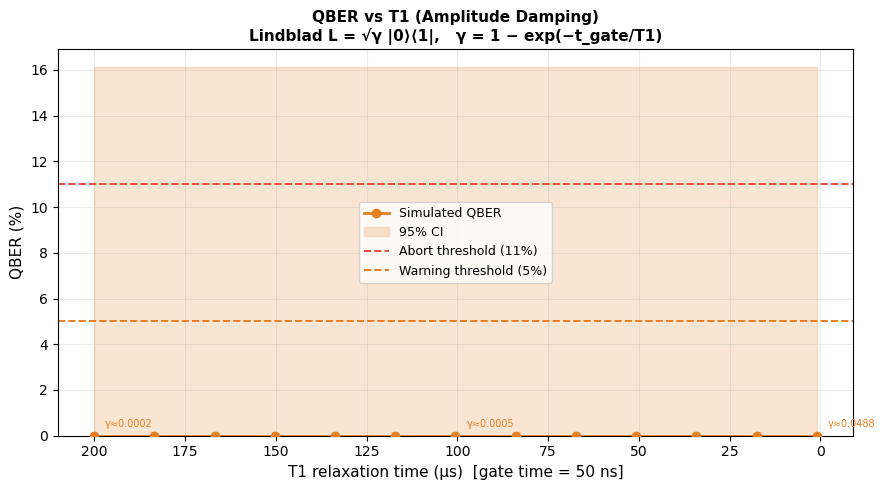

In [6]:
fig = plot_qber_vs_t1(
    n_qubits   = 400,
    gate_ns    = 50.0,
    t1_min_us  = 1.0,
    t1_max_us  = 200.0,
    steps      = 12,
    save_path  = "phase3_qber_vs_t1.png",
)

  Sweeping T1 (amplitude damping)...
  [Channel] Amplitude damping  T1 = 0 µs  γ = 0.3935
    T1=0µs  γ=0.39347  →  QBER=19.6%
  [Channel] Amplitude damping  T1 = 1 µs  γ = 0.0526
    T1=1µs  γ=0.05262  →  QBER=5.2%
  [Channel] Amplitude damping  T1 = 2 µs  γ = 0.0282
    T1=2µs  γ=0.02817  →  QBER=2.1%
  [Channel] Amplitude damping  T1 = 3 µs  γ = 0.0192
    T1=3µs  γ=0.01923  →  QBER=1.0%
  [Channel] Amplitude damping  T1 = 3 µs  γ = 0.0146
    T1=3µs  γ=0.01460  →  QBER=1.0%
  [Channel] Amplitude damping  T1 = 4 µs  γ = 0.0118
    T1=4µs  γ=0.01176  →  QBER=2.1%
  [Channel] Amplitude damping  T1 = 5 µs  γ = 0.0099
    T1=5µs  γ=0.00985  →  QBER=1.0%
  [Channel] Amplitude damping  T1 = 6 µs  γ = 0.0085
    T1=6µs  γ=0.00847  →  QBER=2.1%
  [Channel] Amplitude damping  T1 = 7 µs  γ = 0.0074
    T1=7µs  γ=0.00743  →  QBER=1.0%
  [Channel] Amplitude damping  T1 = 8 µs  γ = 0.0066
    T1=8µs  γ=0.00662  →  QBER=0.0%
  [Channel] Amplitude damping  T1 = 8 µs  γ = 0.0060
    T1=8µs  γ=0.005

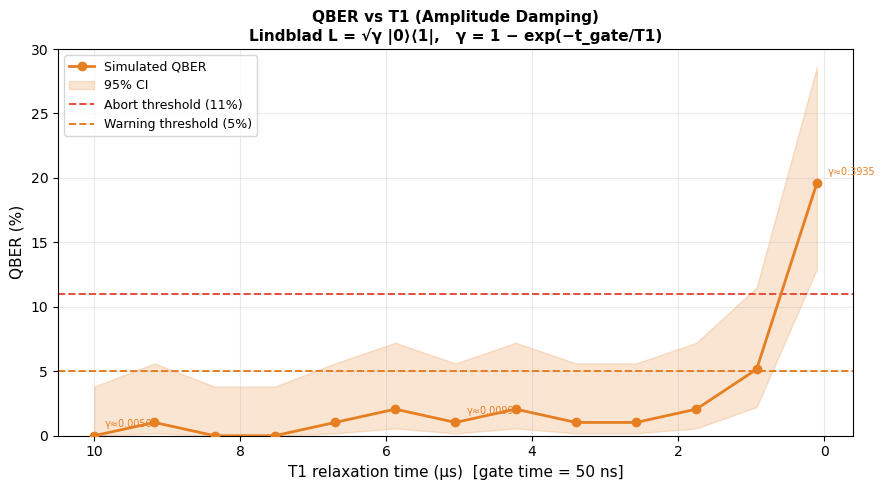

In [9]:
# For amplitude damping and phase damping — use aggressive noise
# so your QBER is detectable with finite qubit counts

T1_NS_DEMO   = 500      # 0.5 µs  — very short T1, γ ≈ 0.095
T2_NS_DEMO   = 400      # 0.4 µs  — very short T2, λ ≈ 0.117
GATE_NS      = 50

# For the comparison table, use 2000 qubits
N = 2000

# For the sweeps, keep the aggressive ranges:
fig = plot_qber_vs_t1(
    n_qubits   = 2000,   # was 400
    gate_ns    = 50.0,
    t1_min_us  = 0.1,    # was 1.0 — go much lower so γ is large
    t1_max_us  = 10.0,   # was 200.0 — stay in the "noisy" regime
    steps      = 12,
)

---
## Cell 7 — QBER vs T2 (Phase Damping)

**Physical meaning:** How long does the qubit maintain phase coherence?

- Phase damping does **not** flip bits — it only randomises the phase
- This primarily affects the **diagonal basis** (|+⟩/|−⟩ states)
- Compare: at equal noise rate, T2 causes less QBER than T1 — can you see why?
  (Hint: rectilinear basis states |0⟩, |1⟩ are not affected by phase damping)

  Sweeping T2 (phase damping)...
  [Channel] Phase damping  T2 = 0 µs  λ = 0.0952
    T2=0.5µs  λ=0.09516  →  QBER=0.0%
  [Channel] Phase damping  T2 = 9 µs  λ = 0.0057
    T2=8.8µs  λ=0.00567  →  QBER=0.0%
  [Channel] Phase damping  T2 = 17 µs  λ = 0.0029
    T2=17.1µs  λ=0.00292  →  QBER=0.0%
  [Channel] Phase damping  T2 = 25 µs  λ = 0.0020
    T2=25.4µs  λ=0.00197  →  QBER=0.0%
  [Channel] Phase damping  T2 = 34 µs  λ = 0.0015
    T2=33.7µs  λ=0.00148  →  QBER=0.0%
  [Channel] Phase damping  T2 = 42 µs  λ = 0.0012
    T2=42.0µs  λ=0.00119  →  QBER=0.0%
  [Channel] Phase damping  T2 = 50 µs  λ = 0.0010
    T2=50.2µs  λ=0.00099  →  QBER=0.0%
  [Channel] Phase damping  T2 = 59 µs  λ = 0.0009
    T2=58.5µs  λ=0.00085  →  QBER=0.0%
  [Channel] Phase damping  T2 = 67 µs  λ = 0.0007
    T2=66.8µs  λ=0.00075  →  QBER=0.0%
  [Channel] Phase damping  T2 = 75 µs  λ = 0.0007
    T2=75.1µs  λ=0.00067  →  QBER=0.0%
  [Channel] Phase damping  T2 = 83 µs  λ = 0.0006
    T2=83.4µs  λ=0.00060  →  QB

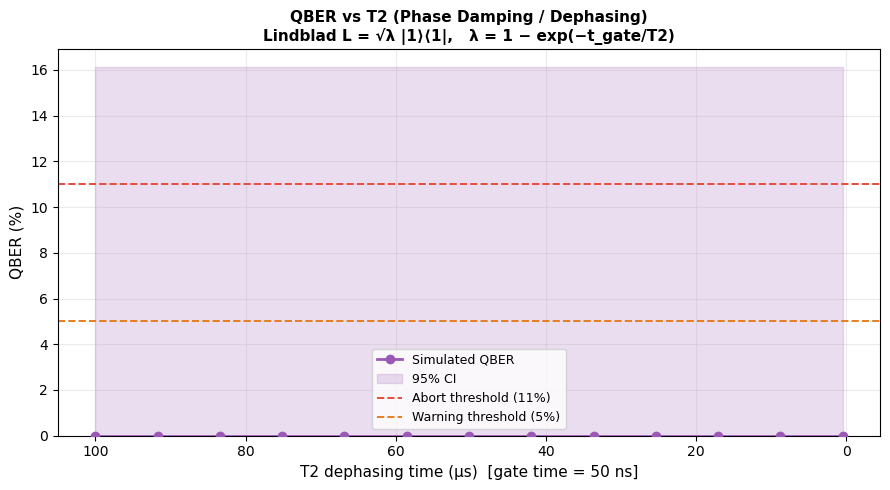

In [7]:
fig = plot_qber_vs_t2(
    n_qubits   = 400,
    gate_ns    = 50.0,
    t2_min_us  = 0.5,
    t2_max_us  = 100.0,
    steps      = 12,
    save_path  = "phase3_qber_vs_t2.png",
)

  Sweeping T2 (phase damping)...
  [Channel] Phase damping  T2 = 0 µs  λ = 0.6321
    T2=0.1µs  λ=0.63212  →  QBER=0.0%
  [Channel] Phase damping  T2 = 0 µs  λ = 0.1025
    T2=0.5µs  λ=0.10247  →  QBER=0.0%
  [Channel] Phase damping  T2 = 1 µs  λ = 0.0555
    T2=0.9µs  λ=0.05554  →  QBER=0.0%
  [Channel] Phase damping  T2 = 1 µs  λ = 0.0381
    T2=1.3µs  λ=0.03809  →  QBER=0.0%
  [Channel] Phase damping  T2 = 2 µs  λ = 0.0290
    T2=1.7µs  λ=0.02898  →  QBER=0.0%
  [Channel] Phase damping  T2 = 2 µs  λ = 0.0234
    T2=2.1µs  λ=0.02339  →  QBER=0.0%
  [Channel] Phase damping  T2 = 3 µs  λ = 0.0196
    T2=2.5µs  λ=0.01961  →  QBER=0.0%
  [Channel] Phase damping  T2 = 3 µs  λ = 0.0169
    T2=2.9µs  λ=0.01688  →  QBER=0.0%
  [Channel] Phase damping  T2 = 3 µs  λ = 0.0148
    T2=3.4µs  λ=0.01481  →  QBER=0.0%
  [Channel] Phase damping  T2 = 4 µs  λ = 0.0132
    T2=3.8µs  λ=0.01320  →  QBER=0.0%
  [Channel] Phase damping  T2 = 4 µs  λ = 0.0119
    T2=4.2µs  λ=0.01190  →  QBER=0.0%
  [Channel

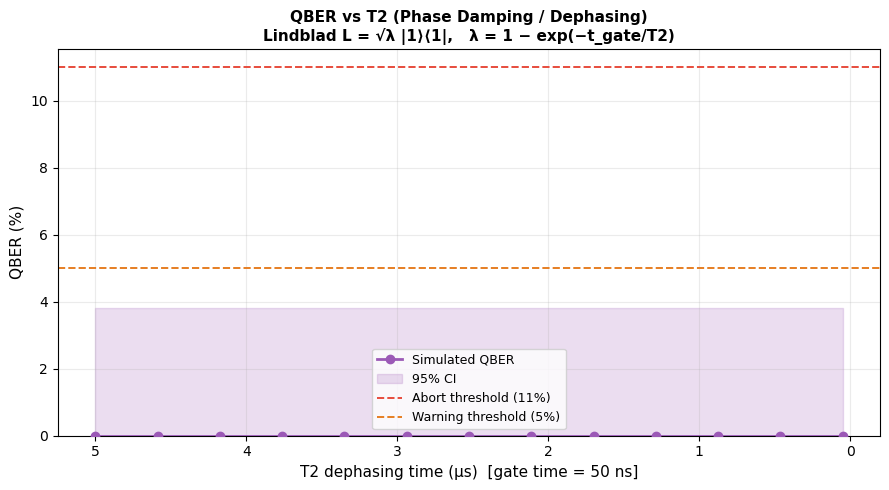

In [10]:
fig = plot_qber_vs_t2(
    n_qubits   = 2000,
    gate_ns    = 50.0,
    t2_min_us  = 0.05,   # was 0.5
    t2_max_us  = 5.0,    # was 100.0
    steps      = 12,
)

---
## Cell 8 — Fiber Loss: QBER + Key Rate vs Distance

**Key insight to observe:**  
- Left panel: QBER stays **flat** (near 0%) regardless of distance  
- Right panel: Key rate **drops exponentially** with distance

This shows that fibre loss is NOT a security threat — it's a *range* limitation.  
Eve cannot exploit it because she cannot insert herself without Bob noticing the photon loss pattern.  
The practical QKD limit without quantum repeaters is ~100–150 km.

  Sweeping fibre channel length...
        0 km  P_survive=1.000  QBER=0.0%  KeyRate=46.2%
       15 km  P_survive=0.501  QBER=0.0%  KeyRate=22.4%
       30 km  P_survive=0.251  QBER=0.0%  KeyRate=11.9%
       45 km  P_survive=0.126  QBER=0.0%  KeyRate=5.6%
       60 km  P_survive=0.063  QBER=0.0%  KeyRate=2.2%
       75 km  P_survive=0.032  QBER=0.0%  KeyRate=1.4%
       90 km  P_survive=0.016  QBER=0.0%  KeyRate=0.9%
      105 km  P_survive=0.008  QBER=0.0%  KeyRate=0.9%
      120 km  P_survive=0.004  QBER=0.0%  KeyRate=0.4%
      135 km  P_survive=0.002  QBER=0.0%  KeyRate=0.1%
      150 km  P_survive=0.001  QBER=0.0%  KeyRate=0.1%
  [✓] Saved → phase3_fiber_loss.png


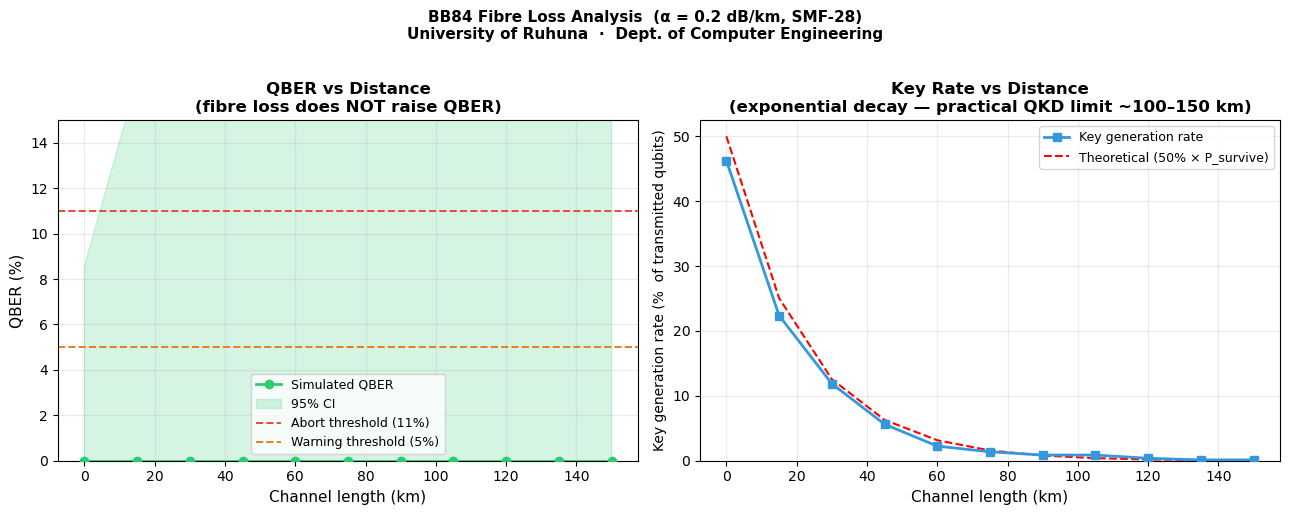

In [8]:
fig = plot_fiber_loss_analysis(
    n_qubits  = 800,
    km_max    = 150.0,
    steps     = 10,
    save_path = "phase3_fiber_loss.png",
)

---
## Summary: What Phase 3 added

| Feature | Phase 1 | Phase 3 |
|---|---|---|
| Noise model | Depolarizing only | Depolarizing + Amplitude Damping + Phase Damping + Combined + Fiber Loss |
| Physical basis | Pauli errors | Lindblad master equation (T1/T2) |
| Photon loss | Not modelled | ✓ Beer-Lambert fibre model |
| QBER vs noise sweeps | Eve sweep only | ✓ p, T1, T2, distance sweeps |

